In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import scipy
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [3]:
end_date = datetime.today()
print(end_date)

2026-05-21 09:45:44.690598


In [4]:
start_date = end_date - timedelta(3*365)
print(start_date)

2023-05-22 09:45:44.690598


In [5]:
ticker = ['UEC']
df = yf.download(ticker, start = start_date, end = end_date, auto_adjust=False, actions = False)

[*********************100%***********************]  1 of 1 completed


In [6]:
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,UEC,UEC,UEC,UEC,UEC,UEC
Date,,,,,,
2023-05-22,2.73,2.73,2.80,2.55,2.55,4271600
2023-05-23,2.79,2.79,2.79,2.69,2.73,3238700
2023-05-24,2.69,2.69,2.78,2.64,2.74,3776600
2023-05-25,2.64,2.64,2.70,2.62,2.66,3612000
2023-05-26,2.57,2.57,2.65,2.55,2.64,3095900


In [7]:
returns = df['Adj Close'].pct_change(fill_method=None).dropna()
returns

Ticker,UEC
Date,
2023-05-23,0.021978
2023-05-24,-0.035842
2023-05-25,-0.018587
2023-05-26,-0.026515
2023-05-30,-0.031128
...,...
2026-05-14,-0.036435
2026-05-15,-0.078326
2026-05-18,-0.032967


In [8]:
log_returns = np.log(1+returns) 
log_returns

Ticker,UEC
Date,
2023-05-23,0.021740
2023-05-24,-0.036500
2023-05-25,-0.018762
2023-05-26,-0.026873
2023-05-30,-0.031623
...,...
2026-05-14,-0.037115
2026-05-15,-0.081563
2026-05-18,-0.033523


In [13]:
#rolling volatility for 30 days
rolling_vol_30 = log_returns.rolling(window=30).std().dropna()
rolling_vol_30_annualized = rolling_vol_30 * np.sqrt(252)
print(rolling_vol_30)
print(rolling_vol_30_annualized)

Ticker           UEC
Date                
2023-07-06  0.031178
2023-07-07  0.031063
2023-07-10  0.030366
2023-07-11  0.031076
2023-07-12  0.030474
...              ...
2026-05-14  0.048111
2026-05-15  0.050511
2026-05-18  0.050809
2026-05-19  0.054070
2026-05-20  0.054302

[722 rows x 1 columns]
Ticker           UEC
Date                
2023-07-06  0.494929
2023-07-07  0.493113
2023-07-10  0.482048
2023-07-11  0.493311
2023-07-12  0.483759
...              ...
2026-05-14  0.763741
2026-05-15  0.801833
2026-05-18  0.806570
2026-05-19  0.858328
2026-05-20  0.862023

[722 rows x 1 columns]


In [15]:
#rolling volatility for 60 days
rolling_vol_60 = log_returns.rolling(window=60).std().dropna()
rolling_vol_60_annualized = rolling_vol_60 * np.sqrt(252)
print(rolling_vol_60)
print(rolling_vol_60_annualized)

Ticker           UEC
Date                
2023-08-17  0.029894
2023-08-18  0.030154
2023-08-21  0.030397
2023-08-22  0.030250
2023-08-23  0.029930
...              ...
2026-05-14  0.045354
2026-05-15  0.046506
2026-05-18  0.046649
2026-05-19  0.048355
2026-05-20  0.049220

[692 rows x 1 columns]
Ticker           UEC
Date                
2023-08-17  0.474558
2023-08-18  0.478675
2023-08-21  0.482545
2023-08-22  0.480196
2023-08-23  0.475119
...              ...
2026-05-14  0.719965
2026-05-15  0.738264
2026-05-18  0.740535
2026-05-19  0.767610
2026-05-20  0.781350

[692 rows x 1 columns]


In [17]:
#rolling volatility for 252 days
rolling_vol_252 = log_returns.rolling(window=252).std().dropna()
rolling_vol_252_annualized = rolling_vol_252 * np.sqrt(252)
print(rolling_vol_252)
print(rolling_vol_252_annualized)

Ticker           UEC
Date                
2024-05-22  0.031740
2024-05-23  0.031722
2024-05-24  0.031666
2024-05-28  0.031680
2024-05-29  0.031686
...              ...
2026-05-14  0.048073
2026-05-15  0.048372
2026-05-18  0.048422
2026-05-19  0.048717
2026-05-20  0.048856

[500 rows x 1 columns]
Ticker           UEC
Date                
2024-05-22  0.503859
2024-05-23  0.503579
2024-05-24  0.502683
2024-05-28  0.502900
2024-05-29  0.502999
...              ...
2026-05-14  0.763132
2026-05-15  0.767887
2026-05-18  0.768681
2026-05-19  0.773365
2026-05-20  0.775563

[500 rows x 1 columns]


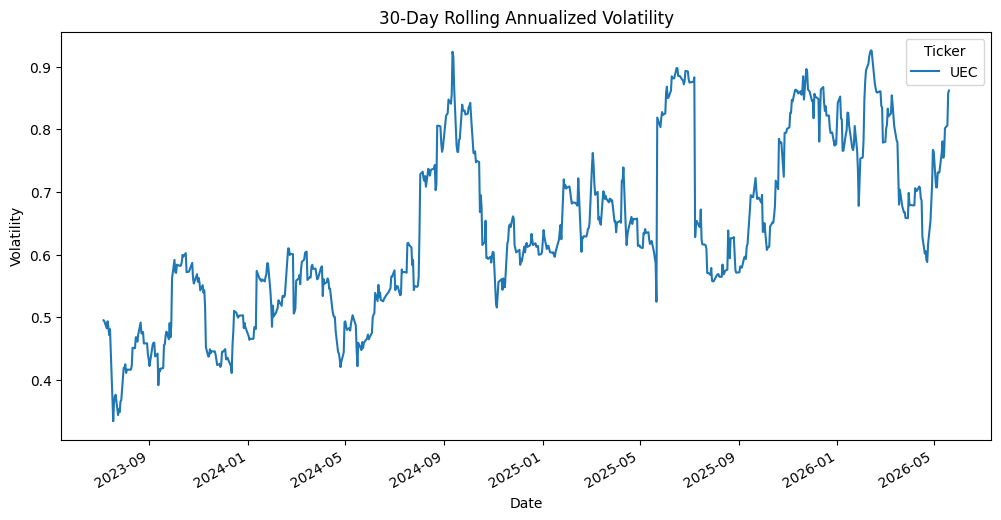

In [20]:
#visualizing volatility over time
#for 30 day window
rolling_vol_30_annualized.plot(figsize=(12,6), title="30-Day Rolling Annualized Volatility")
plt.ylabel("Volatility")
plt.xlabel("Date")
plt.show()

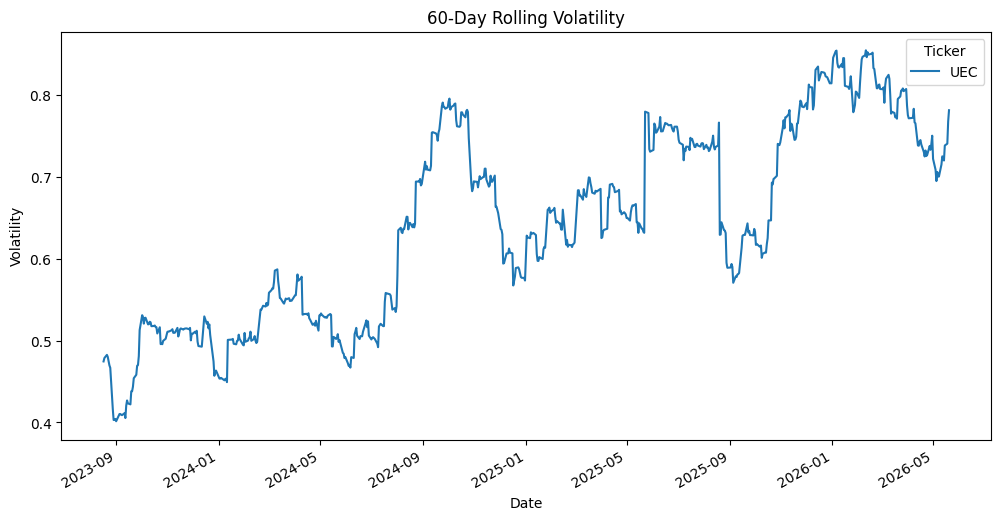

In [21]:
#for 60 day window
rolling_vol_60_annualized.plot(figsize=(12,6), title = "60-Day Rolling Volatility")
plt.ylabel("Volatility")
plt.xlabel("Date")
plt.show()

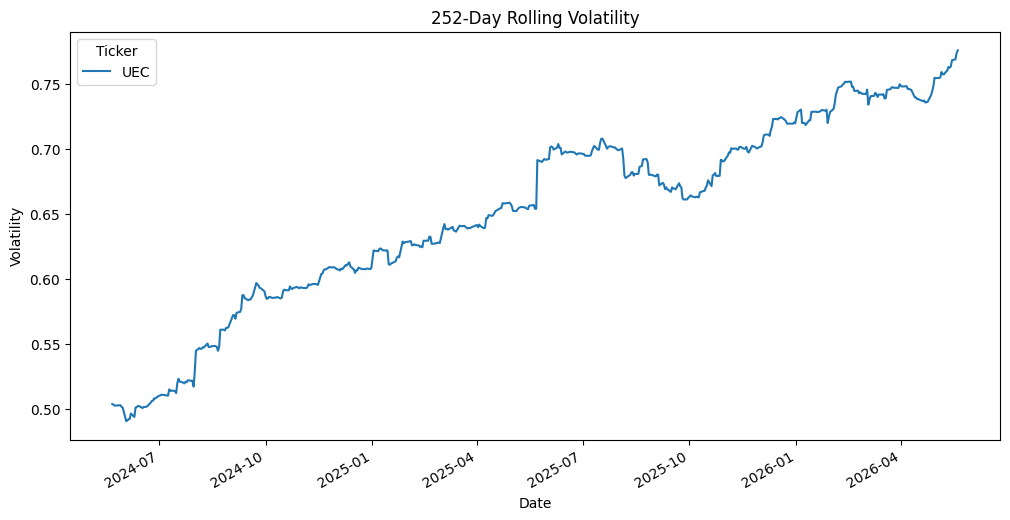

In [24]:
#for 252 day window
rolling_vol_252_annualized.plot(figsize=(12,6), title="252-Day Rolling Volatility")
plt.ylabel("Volatility")
plt.xlabel("Date")
plt.show()